In [ ]:
# 1️⃣ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


--- Clustering ---

In [ ]:
import pandas as pd

# Path to your Drive folder
base = "/content/drive/MyDrive/Dat Capstone"

# Load both CSVs
products = pd.read_csv(f"{base}/cleaned_makeup_products.csv")
reviews = pd.read_csv(f"{base}/cleaned_makeup_reviews.csv")

# Check shapes and preview
print("Products shape:", products.shape)
print("Reviews shape:", reviews.shape)

display(products.head())
display(reviews.head())


/tmp/ipython-input-2687498157.py:8: DtypeWarning: Columns (15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv(f"{base}/cleaned_makeup_reviews.csv")


Products shape: (1373, 35)
Reviews shape: (314029, 27)


,product_link_id,product_link,category,item_id,product_name,brand,price,num_shades,rating,num_reviews,...,rating_count,review_count,average_rating,recommended_ratio,native_review_count,native_sampling_review_count,native_community_content_review_count,syndicated_review_count,faceoff_negative,faceoff_positive
0,8,https://www.ulta.com/p/futurist-skin-tint-seru...,NaN,2612458.0,Futurist Skin Tint Serum Foundation SPF 20,Find your shade,55.0,NaN,4.4,951.0,...,951,951,4.36,0.91,53,NaN,0,898,"""I like this but I don't love it. I typically ...","""ï»¿I received the Estee Lauder Futurist SkinT..."
1,13,https://www.ulta.com/p/dior-forever-fluid-skin...,NaN,2605037.0,Dior Forever Fluid Skin Glow Foundation,Dior,57.0,42.0,4.5,2234.0,...,2234,2234,4.53,0.90,64,NaN,0,2170,"""*All photos are taken in the natural light an...","""I received the Dior Forever Skin Glow foundat..."
2,22,https://www.ulta.com/p/barepro-24hr-wear-skin-...,NaN,2619782.0,BAREPRO 24HR Wear Skin-Perfecting Matte Liquid...,bareMinerals,44.0,NaN,4.1,3359.0,...,3360,3360,4.09,0.81,2254,NaN,0,1106,"""I was having problems with all the drug store...","""I am completely shocked by how amazing this f..."
3,32,https://www.ulta.com/p/futurist-hydra-rescue-m...,NaN,2559137.0,Futurist Hydra Rescue Moisturizing Foundation ...,Estée Lauder,55.0,NaN,4.4,5071.0,...,5071,5071,4.36,0.96,864,NaN,0,4207,"""I give this product a 3 star because I didn't...","""I am 1W2 Sand color and it matches really wel..."
4,15,https://www.ulta.com/p/mini-cc-cream-with-spf-...,Foundation,2603710.0,Mini CC+ Cream with SPF 50+,IT Cosmetics,22.0,NaN,4.3,28718.0,...,28722,28722,4.30,0.87,18366,NaN,0,10356,"""I bought this at the end of January, I only w...","""I ordered the cc cream because it had more sh..."


,unique_review_id,product_link_id,review_id,type,id,ugc_id,legacy_id,internal_review_id,headline,nickname,...,locale,location,bottom_line,product_page_id,upc,gtin,is_staff_reviewer,is_verified_buyer,is_verified_reviewer,helpful_score
0,1,8,521867580,image,521867563.0,NaN,NaN,-1,2C3 Fresco,Dinara,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1
1,2,8,485614895,image,485614799.0,NaN,NaN,-1,Glowing Skin!,Stephie,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1
2,3,8,485250956,image,485250927.0,NaN,NaN,-1,Love it,Cgbanks30,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1
3,4,8,485086522,video,485086531.0,NaN,NaN,-1,Horrible allergic reaction,Genny,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1
4,5,8,482905142,image,482905180.0,NaN,NaN,-1,Futurist Skin tint,Santro3822,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1


In [ ]:
# --- Core ---
import pandas as pd
import numpy as np

# --- Modeling & evaluation ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# --- Utils & plots ---
import matplotlib.pyplot as plt
import textwrap
import os
from pathlib import Path
np.random.seed(42)


In [ ]:
base = "/content/drive/MyDrive/Dat Capstone"          # <-- change if needed
csv_path = f"{base}/cleaned_makeup_products.csv"

# low_memory=False avoids the mixed dtype warning, and we'll coerce numeric below
df = pd.read_csv(csv_path, low_memory=False)

print("Shape:", df.shape)
display(df.head(3))

# optional: peek at dtypes to see text vs numeric
df.info()

Shape: (1373, 35)


,product_link_id,product_link,category,item_id,product_name,brand,price,num_shades,rating,num_reviews,...,rating_count,review_count,average_rating,recommended_ratio,native_review_count,native_sampling_review_count,native_community_content_review_count,syndicated_review_count,faceoff_negative,faceoff_positive
0,8,https://www.ulta.com/p/futurist-skin-tint-seru...,NaN,2612458.0,Futurist Skin Tint Serum Foundation SPF 20,Find your shade,55.0,NaN,4.4,951.0,...,951,951,4.36,0.91,53,NaN,0,898,"""I like this but I don't love it. I typically ...","""ï»¿I received the Estee Lauder Futurist SkinT..."
1,13,https://www.ulta.com/p/dior-forever-fluid-skin...,NaN,2605037.0,Dior Forever Fluid Skin Glow Foundation,Dior,57.0,42.0,4.5,2234.0,...,2234,2234,4.53,0.90,64,NaN,0,2170,"""*All photos are taken in the natural light an...","""I received the Dior Forever Skin Glow foundat..."
2,22,https://www.ulta.com/p/barepro-24hr-wear-skin-...,NaN,2619782.0,BAREPRO 24HR Wear Skin-Perfecting Matte Liquid...,bareMinerals,44.0,NaN,4.1,3359.0,...,3360,3360,4.09,0.81,2254,NaN,0,1106,"""I was having problems with all the drug store...","""I am completely shocked by how amazing this f..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1373 entries, 0 to 1372
Data columns (total 35 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   product_link_id                        1373 non-null   int64  
 1   product_link                           1373 non-null   object 
 2   category                               1351 non-null   object 
 3   item_id                                853 non-null    float64
 4   product_name                           1373 non-null   object 
 5   brand                                  930 non-null    object 
 6   price                                  1373 non-null   float64
 7   num_shades                             64 non-null     float64
 8   rating                                 1232 non-null   float64
 9   num_reviews                            1372 non-null   float64
 10  description                            1373 non-null   object 
 11  pros

In [ ]:
# 2) define columns & clean (IDs/text dropped, numerics kept) — SAFE

expected_cols = [
    "product_link_id","product_link","category","item_id","product_name","brand","price","num_shades",
    "rating","num_reviews","description","pros","cons","best_uses","describe_yourself",
    "review_star_1","review_star_2","review_star_3","review_star_4","review_star_5",
    "rating_star_1","rating_star_2","rating_star_3","rating_star_4","rating_star_5",
    "rating_count","review_count","average_rating","recommended_ratio",
    "native_review_count","native_sampling_review_count",
    # "native_community_count",   # <-- not present in your file; comment out or let code skip missing
    "syndicated_review_count","faceoff_negative","faceoff_positive"
]

present_cols = [c for c in expected_cols if c in df.columns]
missing_cols = sorted(set(expected_cols) - set(df.columns))
print("Missing (ignored):", missing_cols)

# drop ID/url/text/meta for clustering (keep for reporting later)
drop_cols = [
    "product_link_id","product_link","item_id","product_name",
    "description","pros","cons","best_uses","describe_yourself","brand","category"
]
drop_cols = [c for c in drop_cols if c in df.columns]  # keep only those that exist

# candidate numeric features (that actually exist)
num_cols = [c for c in present_cols if c not in drop_cols]
print("Candidate numeric columns:", num_cols)

# coerce everything in num_cols to numeric where possible
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

numeric_df = df.loc[:, num_cols].copy()
numeric_df = numeric_df.dropna(axis=1, how="all")

print("Numeric columns retained:", list(numeric_df.columns))
display(numeric_df.describe().T.round(3).head(15))


Missing (ignored): []
Candidate numeric columns: ['price', 'num_shades', 'rating', 'num_reviews', 'review_star_1', 'review_star_2', 'review_star_3', 'review_star_4', 'review_star_5', 'rating_star_1', 'rating_star_2', 'rating_star_3', 'rating_star_4', 'rating_star_5', 'rating_count', 'review_count', 'average_rating', 'recommended_ratio', 'native_review_count', 'native_sampling_review_count', 'syndicated_review_count', 'faceoff_negative', 'faceoff_positive']
Numeric columns retained: ['price', 'num_shades', 'rating', 'num_reviews', 'review_star_1', 'review_star_2', 'review_star_3', 'review_star_4', 'review_star_5', 'rating_star_1', 'rating_star_2', 'rating_star_3', 'rating_star_4', 'rating_star_5', 'rating_count', 'review_count', 'average_rating', 'recommended_ratio', 'native_review_count', 'syndicated_review_count']


,count,mean,std,min,25%,50%,75%,max
price,1373.0,26.744,15.341,1.5,12.99,26.0,38.0,85.0
num_shades,64.0,21.516,18.815,2.0,3.00,20.0,36.0,67.0
rating,1232.0,4.309,0.383,1.8,4.20,4.4,4.6,4.9
num_reviews,1372.0,1060.634,2869.369,1.0,53.00,290.5,886.5,37663.0
review_star_1,1373.0,235.356,1093.094,0.0,4.00,25.0,120.0,30485.0
review_star_2,1373.0,237.086,852.624,0.0,5.00,27.0,143.0,18736.0
review_star_3,1373.0,160.392,749.831,0.0,4.00,23.0,99.0,18736.0
review_star_4,1373.0,162.136,879.618,0.0,4.00,22.0,88.0,21758.0
review_star_5,1373.0,265.355,1231.178,0.0,5.00,28.0,159.0,30485.0
rating_star_1,1373.0,235.712,1093.341,0.0,4.00,25.0,121.0,30485.0


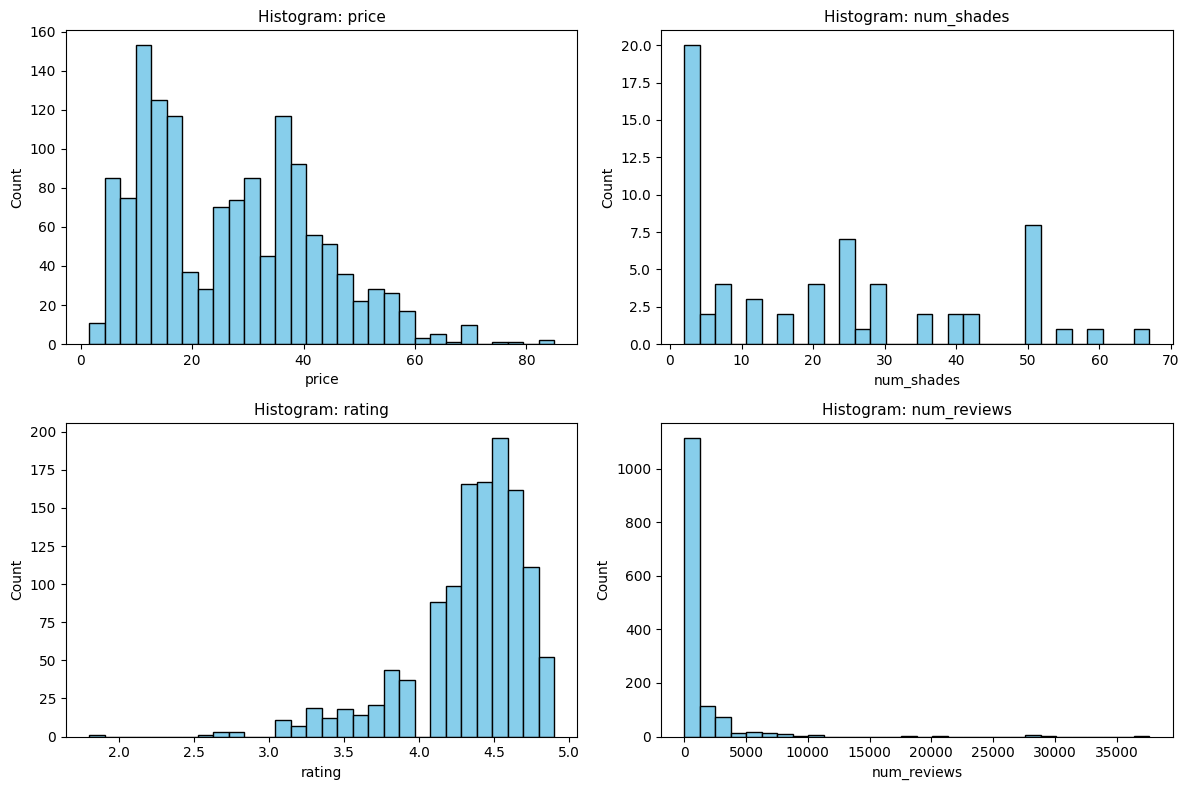

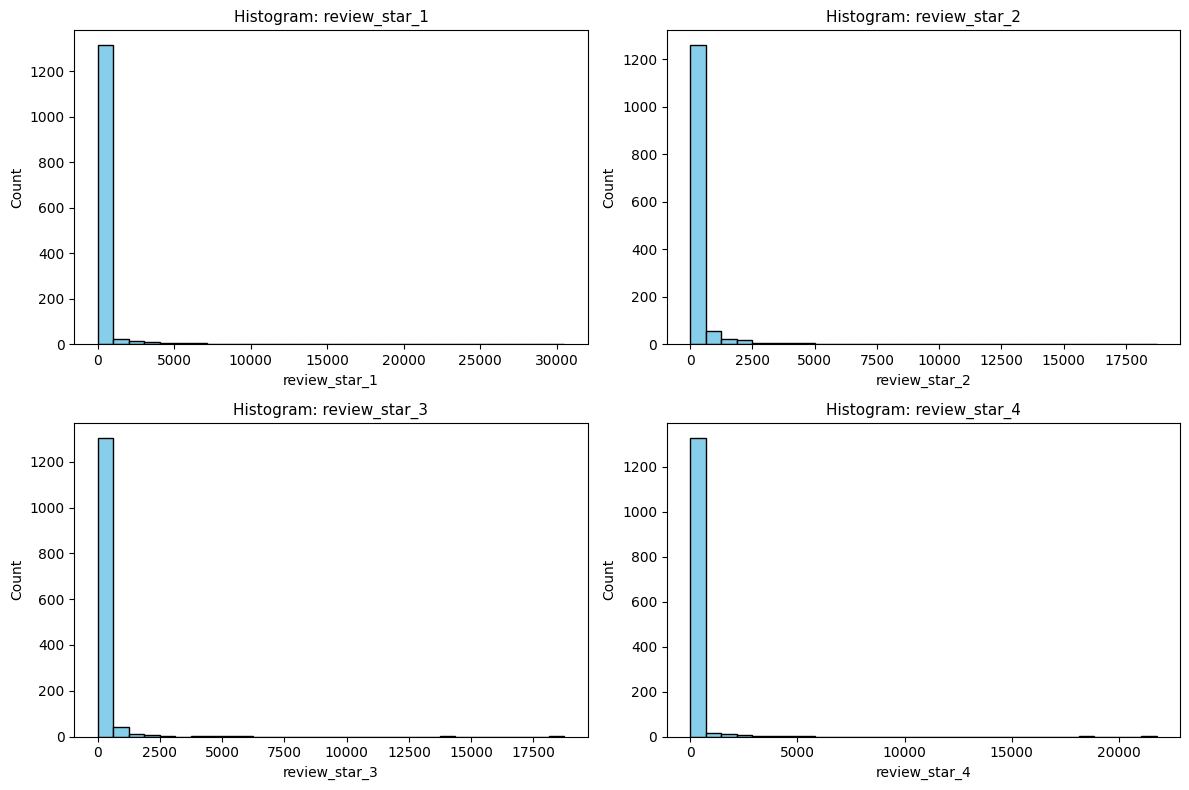

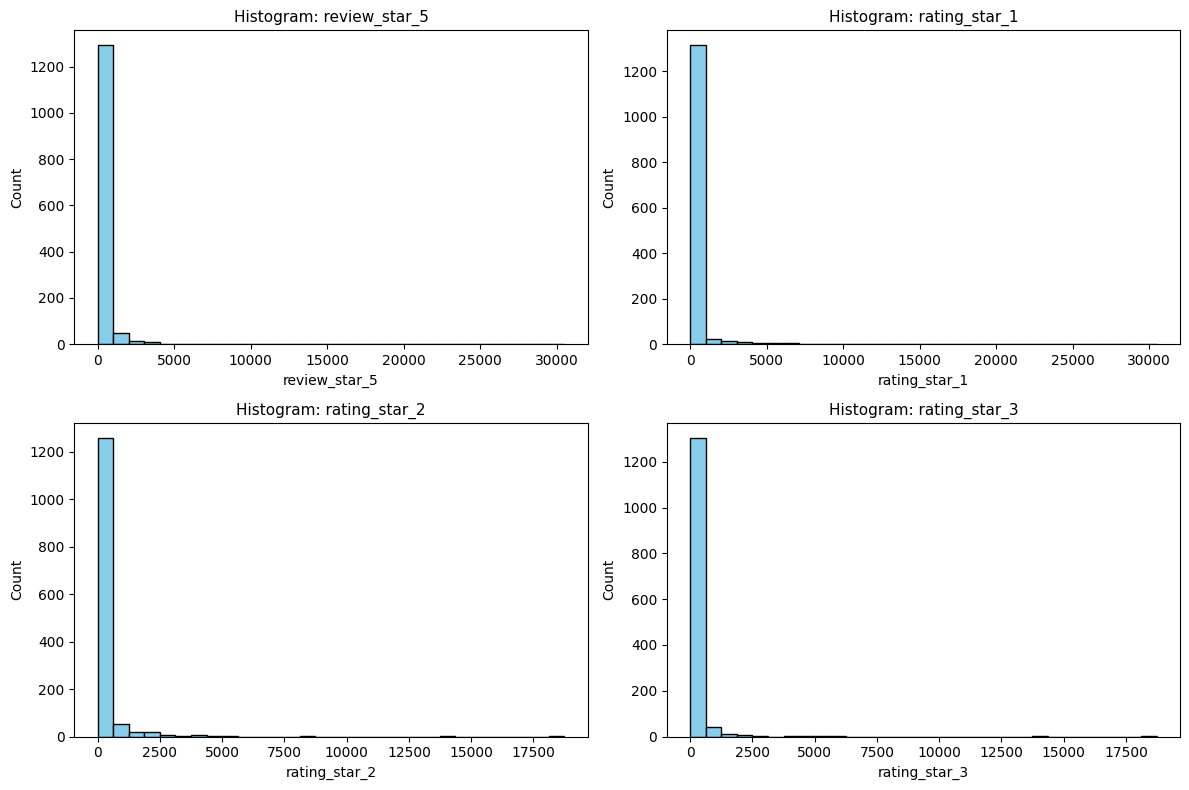

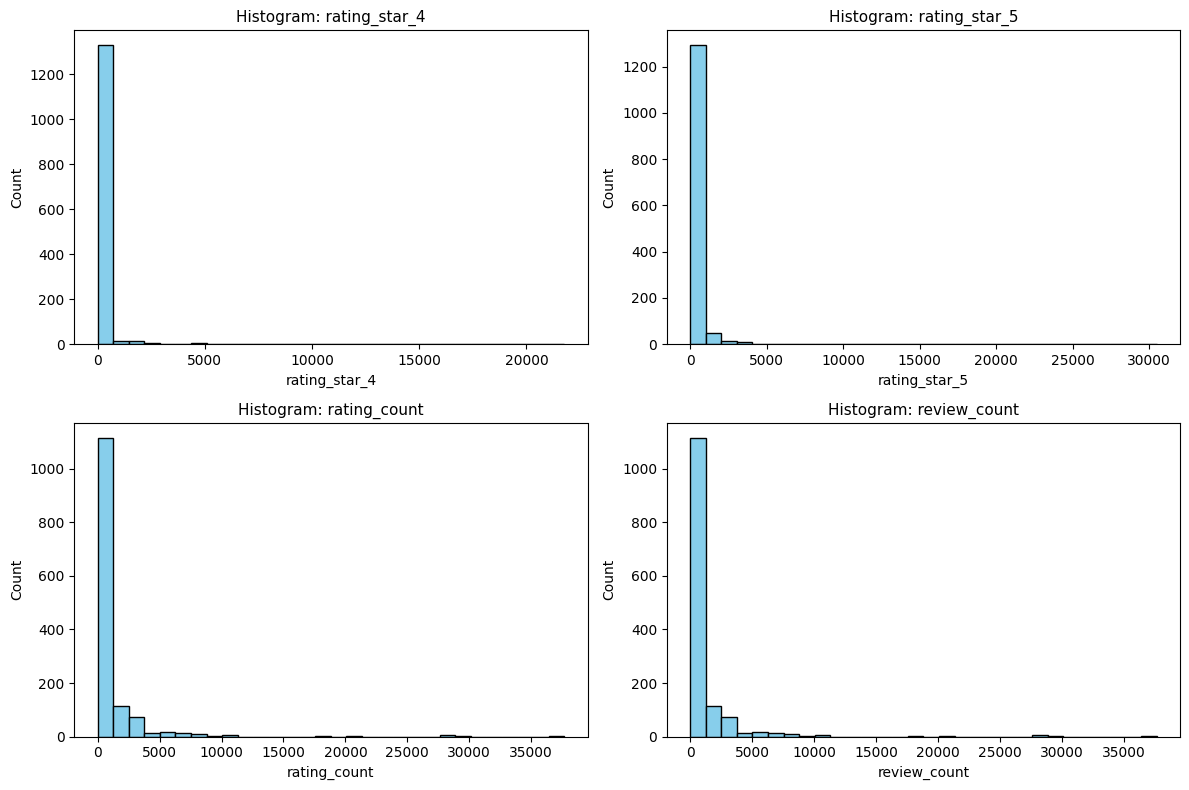

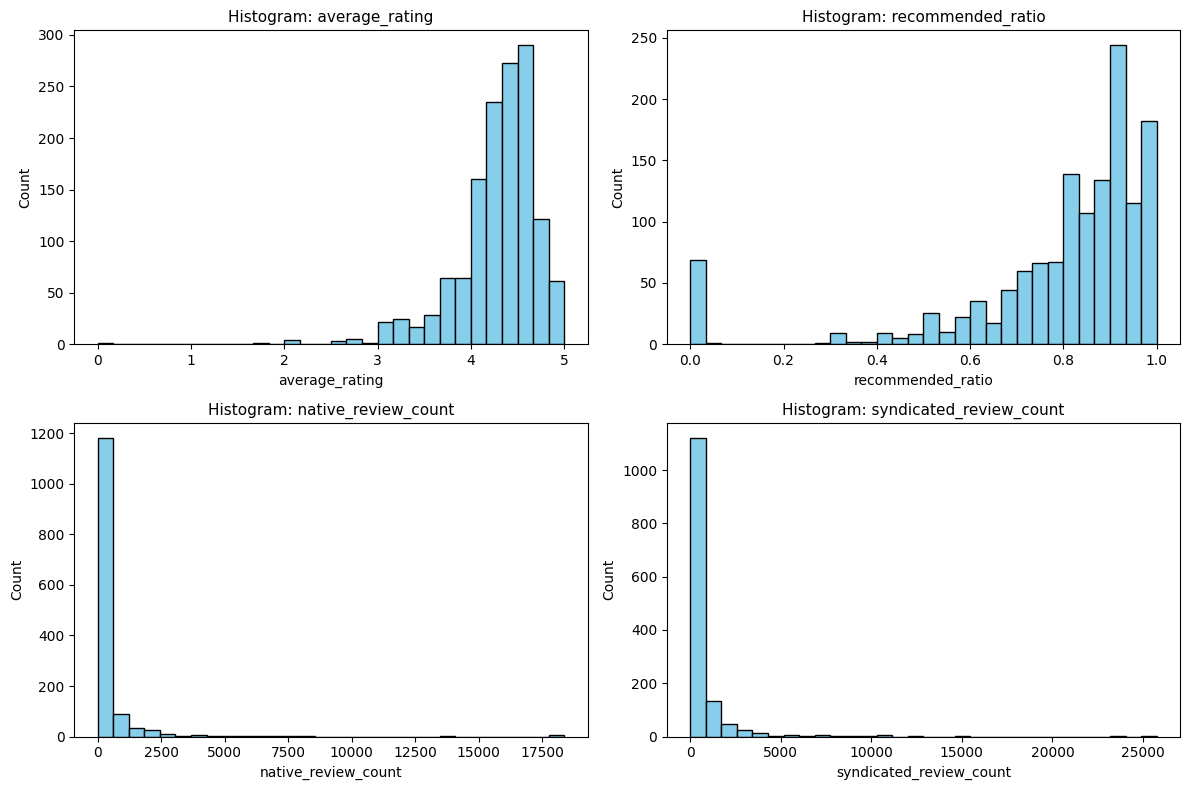

In [ ]:
import math
import matplotlib.pyplot as plt

cols = numeric_df.columns
n = len(cols)
plots_per_fig = 4  # 2x2 layout → 4 plots per figure

for start in range(0, n, plots_per_fig):
    end = min(start + plots_per_fig, n)
    subset = cols[start:end]

    nrows, ncols = 2, 2
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 8))
    axes = axes.flatten()

    for i, c in enumerate(subset):
        ax = axes[i]
        ax.hist(numeric_df[c].dropna(), bins=30, color="skyblue", edgecolor="black")
        ax.set_title(f"Histogram: {c}", fontsize=11)
        ax.set_xlabel(c)
        ax.set_ylabel("Count")

    # hide unused subplots if fewer than 4 left
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    fig_num = start // plots_per_fig + 1
    plt.savefig(f"{base}/basic_eda_part{fig_num}.png", dpi=160, bbox_inches="tight")
    plt.show()


In [ ]:
# Step 4: Handle missing values

X = numeric_df.copy()
X = X.fillna(X.median(numeric_only=True))

# drop columns with no variance (e.g., same value for all)
low_var = X.nunique() <= 1
if low_var.any():
    print("Dropping near-constant columns:", list(X.columns[low_var]))
    X = X.loc[:, ~low_var]


In [ ]:
#Step 5: Log-transform skewed variables
import numpy as np

skew_candidates = [c for c in X.columns if (X[c].max() > 100) and (X[c].min() >= 0)]
print("Skew candidates (log1p transform):", skew_candidates)

X_log = X.copy()
for c in skew_candidates:
    X_log[c] = np.log1p(X[c])  # log1p handles zeros


Skew candidates (log1p transform): ['num_reviews', 'review_star_1', 'review_star_2', 'review_star_3', 'review_star_4', 'review_star_5', 'rating_star_1', 'rating_star_2', 'rating_star_3', 'rating_star_4', 'rating_star_5', 'rating_count', 'review_count', 'native_review_count', 'syndicated_review_count']


In [ ]:
#Step 6: Standardize data (scaling)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_log), columns=X_log.columns, index=X_log.index)

display(X_scaled.head(3))

,price,num_shades,rating,num_reviews,review_star_1,review_star_2,review_star_3,review_star_4,review_star_5,rating_star_1,rating_star_2,rating_star_3,rating_star_4,rating_star_5,rating_count,review_count,average_rating,recommended_ratio,native_review_count,syndicated_review_count
0,1.842533,-0.017474,0.224079,0.727766,1.138838,0.499451,1.590673,-0.121061,-0.015121,1.137744,0.498451,1.589695,-0.122142,-0.016198,0.726555,0.727721,0.162783,0.516759,-0.088802,0.933432
1,1.972950,5.424115,0.499021,1.156053,0.135569,0.297456,0.840843,1.599373,1.831081,0.134314,0.296460,0.839865,1.598158,1.829502,1.154596,1.155896,0.548012,0.472837,0.007982,1.242777
2,1.125236,-0.017474,-0.600748,1.360653,2.085232,1.163040,1.158108,1.215284,1.319713,2.084290,1.162027,1.157130,1.214099,1.318273,1.359228,1.360593,-0.449051,0.077543,1.859325,1.006456


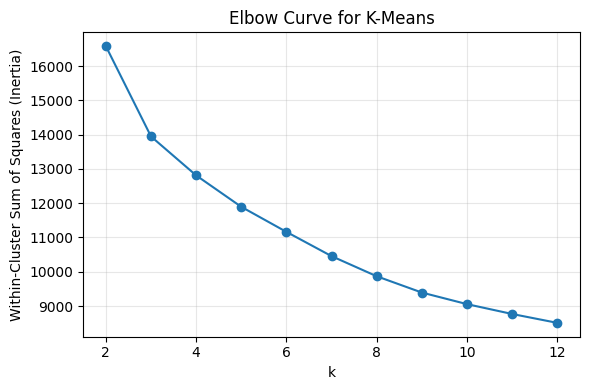

k= 2  inertia=16,583
k= 3  inertia=13,948
k= 4  inertia=12,812
k= 5  inertia=11,894
k= 6  inertia=11,163
k= 7  inertia=10,455
k= 8  inertia=9,868
k= 9  inertia=9,393
k=10  inertia=9,055
k=11  inertia=8,767
k=12  inertia=8,509


In [ ]:

#Step 7: Elbow method
from sklearn.cluster import KMeans

inertias = []
ks = range(2, 13)

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Curve for K-Means")
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dat Capstone/elbow_curve_for_kmeans.png",
            dpi=300, bbox_inches="tight")
plt.show()

for k, s in zip(ks, inertias):
    print(f"k={k:2d}  inertia={s:,.0f}")


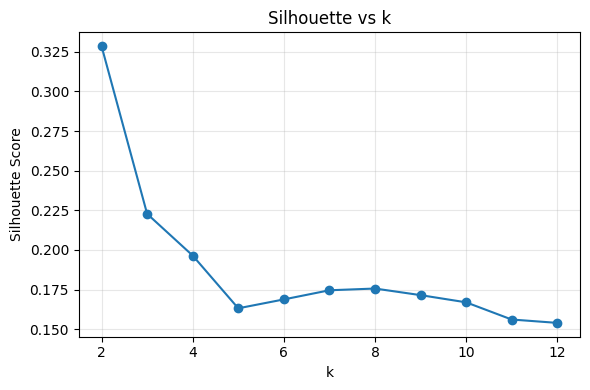

k= 2  silhouette=0.329
k= 3  silhouette=0.223
k= 4  silhouette=0.196
k= 5  silhouette=0.163
k= 6  silhouette=0.169
k= 7  silhouette=0.175
k= 8  silhouette=0.176
k= 9  silhouette=0.171
k=10  silhouette=0.167
k=11  silhouette=0.156
k=12  silhouette=0.154


In [ ]:
#Step 8: Silhouette scores

from sklearn.metrics import silhouette_score

sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(6,4))
plt.plot(list(ks), sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette vs k")
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dat Capstone/silhouette_vs_k.png",
            dpi=300, bbox_inches="tight")
plt.show()

for k, s in zip(ks, sil_scores):
    print(f"k={k:2d}  silhouette={s:.3f}")


In [ ]:
# Choose the best number of clusters based on your plots
k_best = 4  # <-- change this if another value looks better

from sklearn.cluster import KMeans

# Fit K-Means with chosen k
km_final = KMeans(n_clusters=k_best, n_init=50, random_state=42)
labels = km_final.fit_predict(X_scaled)

# Attach labels to original dataframe
df_clusters = df.copy()
df_clusters["cluster"] = labels

print("Cluster sizes:")
print(df_clusters["cluster"].value_counts().sort_index())

# quick look
display(df_clusters[["product_name", "brand", "price", "average_rating", "cluster"]].head(10))


Cluster sizes:
cluster
0    146
1    582
2    312
3    333
Name: count, dtype: int64


,product_name,brand,price,average_rating,cluster
0,Futurist Skin Tint Serum Foundation SPF 20,Find your shade,55.0,4.36,1
1,Dior Forever Fluid Skin Glow Foundation,Dior,57.0,4.53,2
2,BAREPRO 24HR Wear Skin-Perfecting Matte Liquid...,bareMinerals,44.0,4.09,2
3,Futurist Hydra Rescue Moisturizing Foundation ...,Estée Lauder,55.0,4.36,2
4,Mini CC+ Cream with SPF 50+,IT Cosmetics,22.0,4.30,2
5,Teint Idole Ultra Wear 24H Full Coverage Found...,Lancôme,57.0,4.45,2
6,Studio Fix Powder Plus Foundation Makeup,MAC,44.0,4.56,2
7,Light Reflecting Advanced Skincare Foundation,NARS,52.0,4.47,2
8,Studio Fix Fluid SPF15 24HR Matte Foundation +...,MAC,44.0,4.33,1
9,Born This Way Natural Finish Longwear Liquid F...,Too Faced,46.0,4.32,2


In [ ]:
# STEP 9: Final K-Means model
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

k_best = 4  # final chosen k
km_final = KMeans(n_clusters=k_best, n_init=50, random_state=42)
labels = km_final.fit_predict(X_scaled)

df_clusters = df.copy()
df_clusters["cluster"] = labels

print("Cluster sizes:")
print(df_clusters["cluster"].value_counts().sort_index())


Cluster sizes:
cluster
0    146
1    582
2    312
3    333
Name: count, dtype: int64


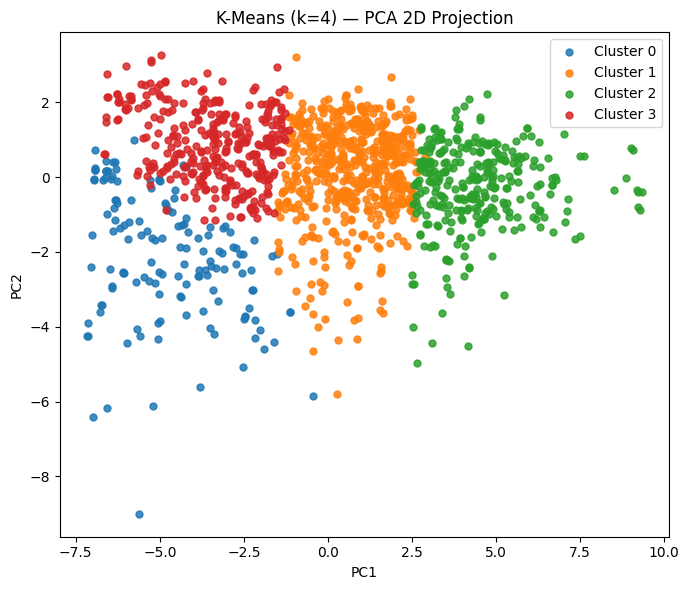

Explained variance ratio: [0.57745109 0.10966273]


In [ ]:
#Step 10 — PCA 2D visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
proj2 = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
for c in range(k_best):
    idx = (labels == c)
    plt.scatter(proj2[idx, 0], proj2[idx, 1], s=25, alpha=.85, label=f"Cluster {c}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means (k={k_best}) — PCA 2D Projection")
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dat Capstone/pca_2d_projection.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


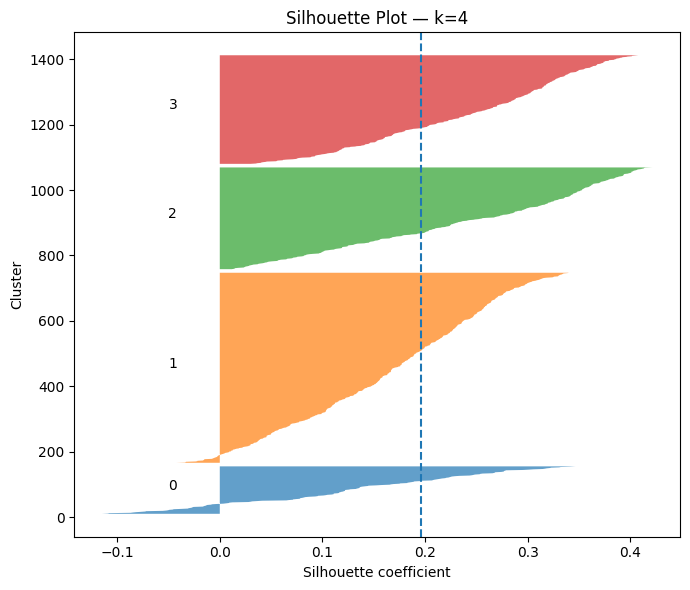

In [ ]:
from sklearn.metrics import silhouette_samples
import numpy as np
import matplotlib.pyplot as plt

sample_sil = silhouette_samples(X_scaled, labels)

y_lower = 10
plt.figure(figsize=(7,6))
for i in range(k_best):
    ith = sample_sil[labels == i]
    ith.sort()
    size_i = ith.shape[0]
    y_upper = y_lower + size_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5*size_i, str(i))
    y_lower = y_upper + 10

plt.axvline(np.mean(sample_sil), linestyle="--")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.title(f"Silhouette Plot — k={k_best}")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dat Capstone/silhouette_plot_k-4vs_k.png",
            dpi=300, bbox_inches="tight")
plt.show()


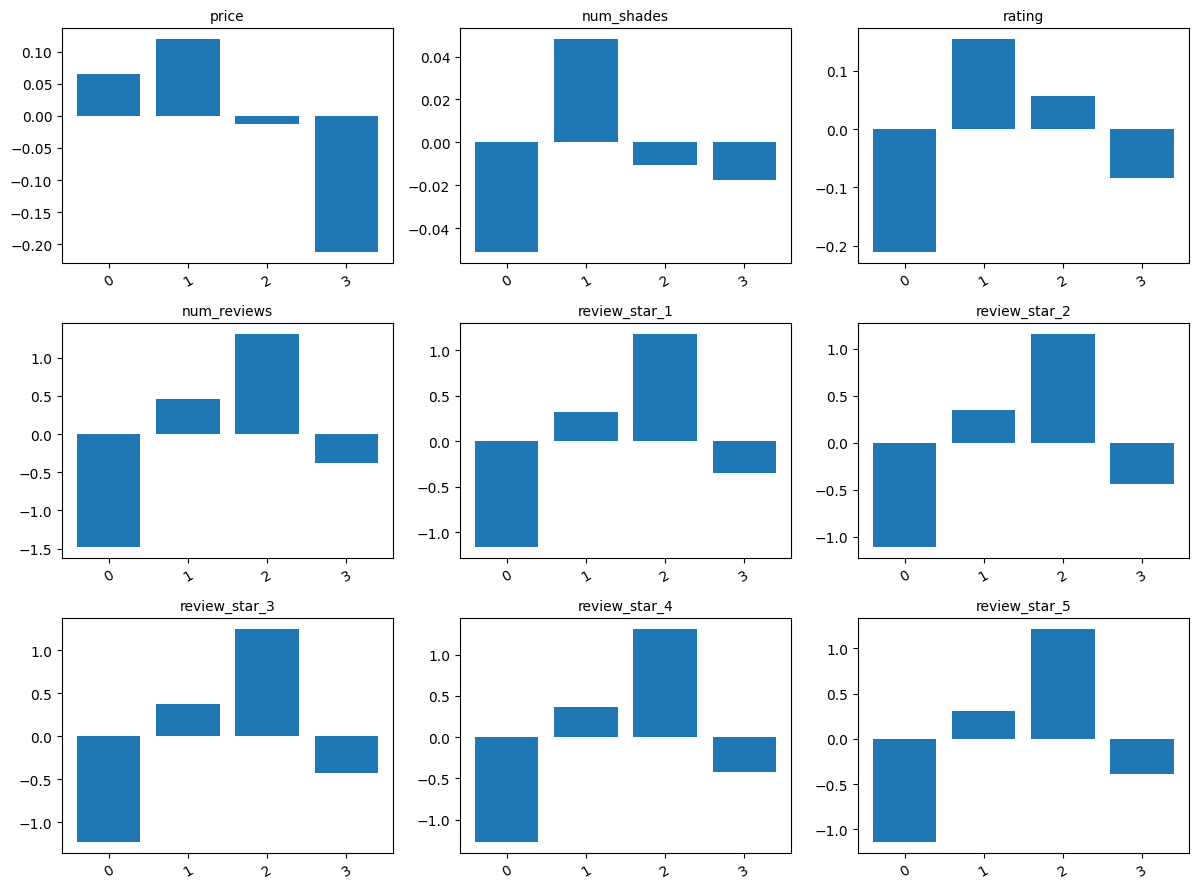

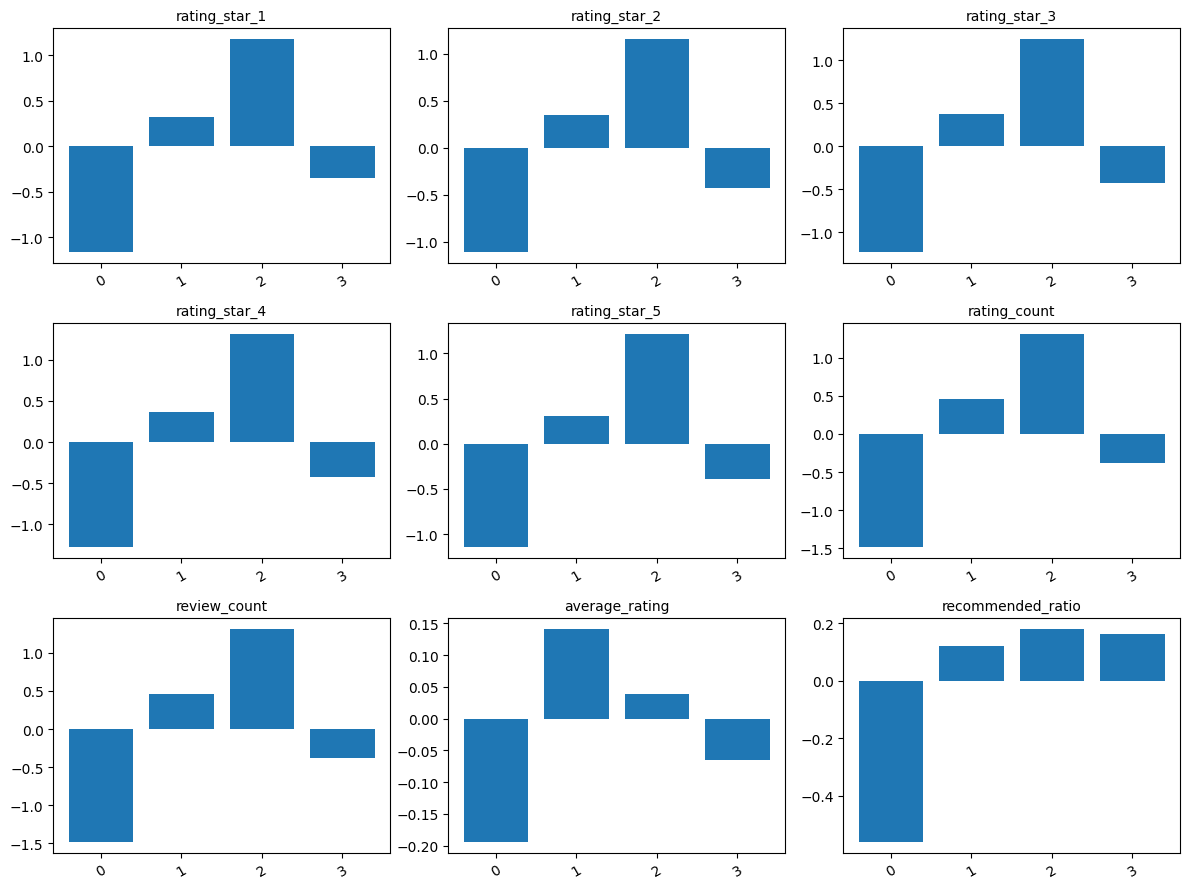

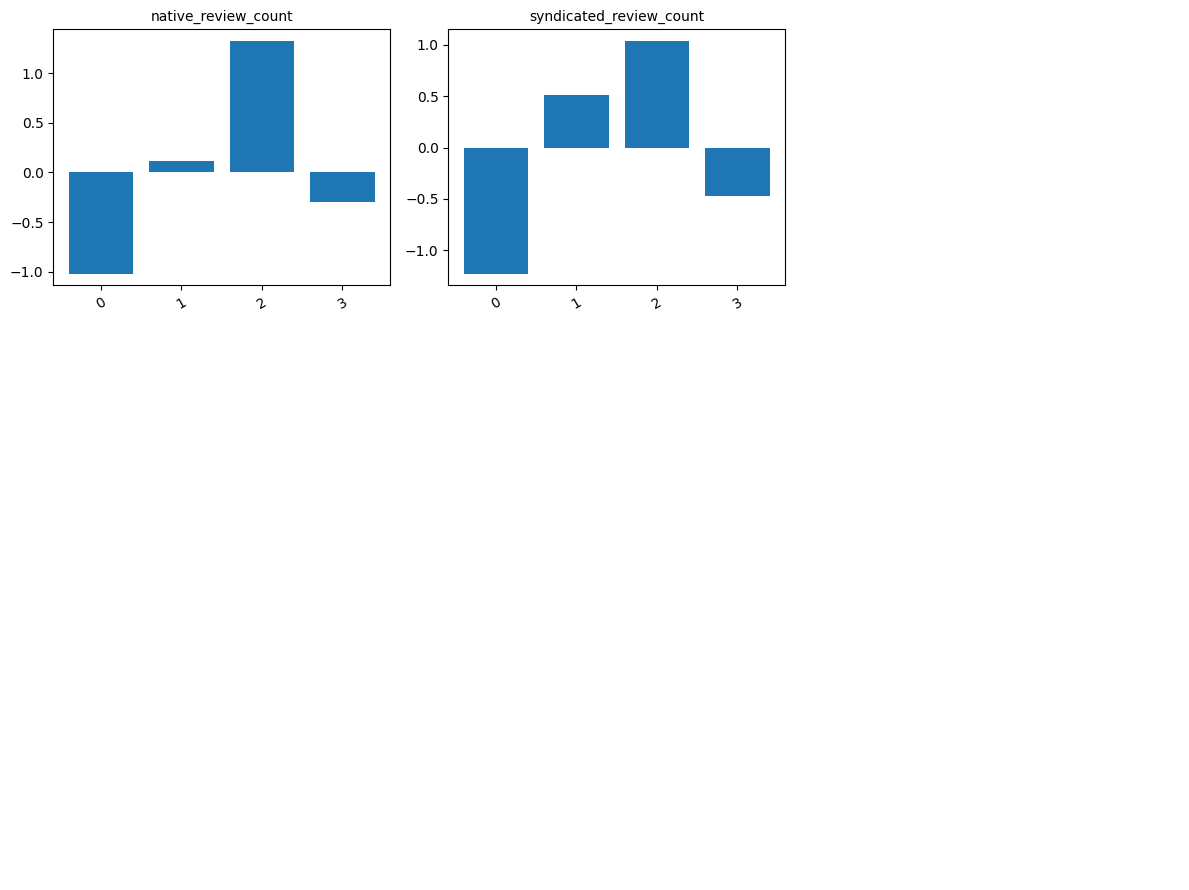

In [ ]:
import matplotlib.pyplot as plt
import math

# assuming you already have X_scaled or your feature data
kmeans = KMeans(n_clusters=k_best, random_state=42)
kmeans.fit(X_scaled)

# convert cluster centers to a DataFrame
centers_orig = pd.DataFrame(kmeans.cluster_centers_, columns=X_scaled.columns)
out_dir = Path(".")  # current directory

# set how many plots per page
cols_per_fig = 3
rows_per_fig = 3
plots_per_fig = cols_per_fig * rows_per_fig

cols = centers_orig.columns.tolist()
num_plots = len(cols)
num_figs = math.ceil(num_plots / plots_per_fig)

for f in range(num_figs):
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset = cols[start:end]

    fig, axes = plt.subplots(rows_per_fig, cols_per_fig, figsize=(12, 9))
    axes = axes.flatten()

    for i, col in enumerate(subset):
        axes[i].bar(centers_orig.index, centers_orig[col].values)
        axes[i].set_title(col, fontsize=10)
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].set_ylabel("")
    # turn off unused subplots
    for j in range(len(subset), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(out_dir / f"centers_grid_summary_{f+1}.png", dpi=160)
    plt.show()


In [ ]:
# Use the exact features that went into modeling
features_used = list(X.columns)

profile_count = df_clusters["cluster"].value_counts().sort_index().rename("count")
profile_mean  = df_clusters.groupby("cluster")[features_used].mean(numeric_only=True).add_suffix("_mean")
profile_med   = df_clusters.groupby("cluster")[features_used].median(numeric_only=True).add_suffix("_median")

profile = pd.concat([profile_count, profile_mean, profile_med], axis=1).sort_index()
display(profile.round(2))

# save profile and labeled dataset
profile.to_csv(out_dir / "06_cluster_profile.csv")
(df_clusters
  .to_csv(out_dir / "products_with_clusters.csv", index=False))

print("Saved:")
print(" -", out_dir / "04_pca_2d.png")
print(" -", out_dir / "05_silhouette_bars.png")
print(" -", out_dir / "centers_logspace.csv")
print(" -", out_dir / "centers_original_units.csv")
print(" -", out_dir / "06_cluster_profile.csv")
print(" -", out_dir / "products_with_clusters.csv")


,count,price_mean,num_shades_mean,rating_mean,num_reviews_mean,review_star_1_mean,review_star_2_mean,review_star_3_mean,review_star_4_mean,review_star_5_mean,...,rating_star_2_median,rating_star_3_median,rating_star_4_median,rating_star_5_median,rating_count_median,review_count_median,average_rating_median,recommended_ratio_median,native_review_count_median,syndicated_review_count_median
cluster,,,,,,,,,,,,,,,,,,,,,
0,146,21.48,5.00,3.64,20.71,4.98,5.25,3.80,2.81,3.83,...,2.0,1.0,1.0,2.0,11.5,11.5,3.67,0.44,10.0,0.0
1,582,26.83,26.90,4.35,459.12,102.45,123.93,70.16,56.02,107.27,...,35.0,29.0,31.0,36.0,399.5,399.5,4.41,0.87,83.0,253.5
2,312,27.00,19.73,4.33,3746.43,829.77,796.27,565.72,602.04,953.10,...,228.0,195.5,220.0,281.0,2238.0,2238.0,4.33,0.85,756.0,1264.0
3,333,28.67,17.25,4.45,48.33,11.72,12.59,6.97,5.29,11.95,...,3.0,3.0,2.0,3.0,37.0,37.0,4.46,0.92,16.0,0.0


Saved:
 - 04_pca_2d.png
 - 05_silhouette_bars.png
 - centers_logspace.csv
 - centers_original_units.csv
 - 06_cluster_profile.csv
 - products_with_clusters.csv


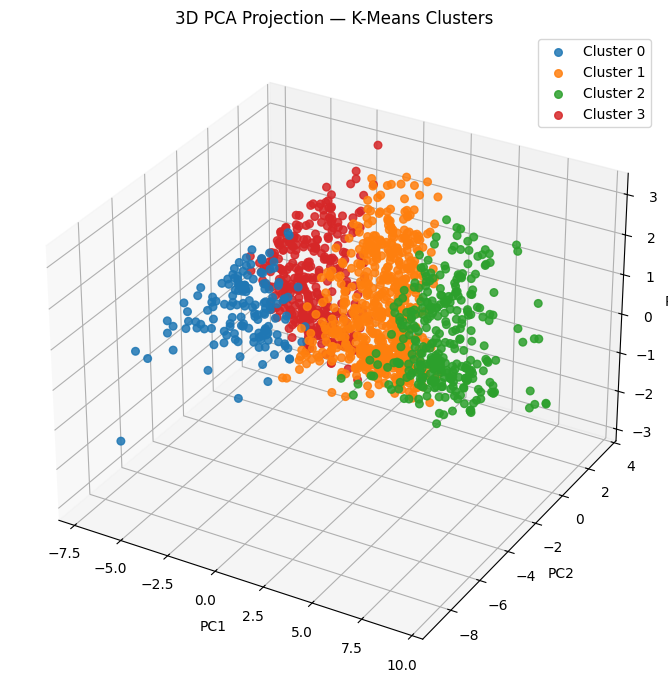

Explained variance ratio (3 components): [0.57745109 0.10966273 0.06119383]


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (for 3D projection)

pca3 = PCA(n_components=3, random_state=42)
proj3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection="3d")

for c in range(k_best):
    idx = labels == c
    ax.scatter(
        proj3[idx,0], proj3[idx,1], proj3[idx,2],
        s=30, alpha=.85, label=f"Cluster {c}"
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection — K-Means Clusters")
ax.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dat Capstone/3d_pca_projection_k-means.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Explained variance ratio (3 components):", pca3.explained_variance_ratio_)


In [ ]:
!pip -q install fastcluster

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 6.1 MB/s eta 0:00:00


In [ ]:

## Hierarchal Clustering

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Optional (faster linkage on big data if installed)
try:
    import fastcluster
except:
    fastcluster = None

np.random.seed(42)

base = "/content/drive/MyDrive/Dat Capstone"
out_dir = Path(base) / "hierarchical_outputs"
out_dir.mkdir(parents=True, exist_ok=True)


In [ ]:
#Load data

df = pd.read_csv(f"{base}/cleaned_makeup_products.csv", low_memory=False)
print("Shape:", df.shape)
df.head(3)



Shape: (1373, 35)


,product_link_id,product_link,category,item_id,product_name,brand,price,num_shades,rating,num_reviews,...,rating_count,review_count,average_rating,recommended_ratio,native_review_count,native_sampling_review_count,native_community_content_review_count,syndicated_review_count,faceoff_negative,faceoff_positive
0,8,https://www.ulta.com/p/futurist-skin-tint-seru...,NaN,2612458.0,Futurist Skin Tint Serum Foundation SPF 20,Find your shade,55.0,NaN,4.4,951.0,...,951,951,4.36,0.91,53,NaN,0,898,"""I like this but I don't love it. I typically ...","""ï»¿I received the Estee Lauder Futurist SkinT..."
1,13,https://www.ulta.com/p/dior-forever-fluid-skin...,NaN,2605037.0,Dior Forever Fluid Skin Glow Foundation,Dior,57.0,42.0,4.5,2234.0,...,2234,2234,4.53,0.90,64,NaN,0,2170,"""*All photos are taken in the natural light an...","""I received the Dior Forever Skin Glow foundat..."
2,22,https://www.ulta.com/p/barepro-24hr-wear-skin-...,NaN,2619782.0,BAREPRO 24HR Wear Skin-Perfecting Matte Liquid...,bareMinerals,44.0,NaN,4.1,3359.0,...,3360,3360,4.09,0.81,2254,NaN,0,1106,"""I was having problems with all the drug store...","""I am completely shocked by how amazing this f..."


In [ ]:
#4) Impute, transform, and build a preprocessing pipeline

# numeric = number dtypes
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
# categorical = object/category/bool (cast bool to category for OHE)
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Work on a copy to keep originals
work = df.copy()

# Simple median impute for numeric
work[num_cols] = work[num_cols].fillna(work[num_cols].median(numeric_only=True))

# Build a ColumnTransformer
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first")
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols)
    ],
    remainder="drop"
)

# Fit/transform to get final feature matrix
X = pre.fit_transform(work)

# Get feature names for later (optional, nice for profiling)
num_names = num_cols
cat_names = []
if len(cat_cols):
    cat_names = list(pre.named_transformers_["cat"].get_feature_names_out(cat_cols))
feature_names = num_names + cat_names

print("Final feature matrix shape:", X.shape)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Final feature matrix shape: (1373, 8444)


In [ ]:
import numpy as np

print("X shape:", X.shape)
print("Any NaN in X?      ", np.isnan(X).any())
print("Any non-finite X?  ", ~np.isfinite(X).all())
# Which rows/cols are bad (optional):
bad_rows = ~np.isfinite(X).all(axis=1)
bad_cols = ~np.isfinite(X).all(axis=0)
print("Bad rows:", bad_rows.sum(), "Bad cols:", bad_cols.sum())



X shape: (1373, 8444)
Any NaN in X?       True
Any non-finite X?   True
Bad rows: 1373 Bad cols: 1


In [ ]:
#4b) Rebuild preprocessing robustly (impute → drop zero-variance → scale → one-hot)

#Rebuild preprocessing robustly (impute → drop zero-variance → scale → one-hot)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
import numpy as np
import pandas as pd

# Start from the original df, and num_cols / cat_cols you already defined earlier
work = df.copy()

# Ensure numeric dtype
for c in num_cols:
    work[c] = pd.to_numeric(work[c], errors="coerce")

# Pipelines
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(threshold=0.0)),  # drop zero-variance numerics (prevents scaler NaNs)
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),      # fill missing categories
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    remainder="drop"
)

X = pre.fit_transform(work)

# ----- Recover feature names (after VT + OHE) -----
# Numeric names after variance threshold
num_mask = pre.named_transformers_["num"].named_steps["var"].get_support()
num_names_kept = [col for col, keep in zip(num_cols, num_mask) if keep]

# Categorical names from OHE
cat_names = []
if len(cat_cols):
    cat_names = list(pre.named_transformers_["cat"].named_steps["ohe"].get_feature_names_out(cat_cols))

feature_names = num_names_kept + cat_names

# Final safety: coerce any stray non-finites (should be none after VT)
if not np.isfinite(X).all():
    print("Warning: non-finite values found post-transform. Coercing with nan_to_num.")
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print("Final feature matrix shape:", X.shape)
print("All finite?", np.isfinite(X).all())
print("Numeric features kept:", len(num_names_kept), " | Categorical features:", len(cat_names))


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['native_sampling_review_count']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Final feature matrix shape: (1373, 8434)
All finite? True
Numeric features kept: 22  | Categorical features: 8412


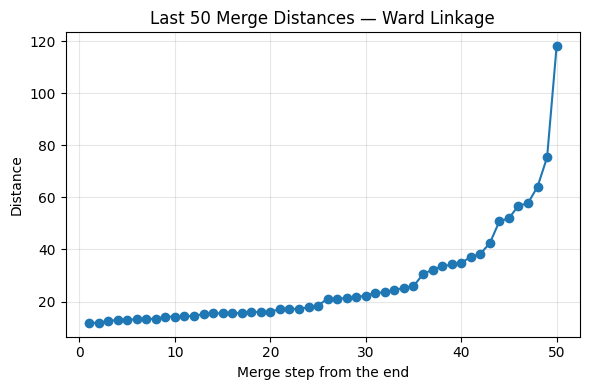

In [ ]:

#5) Linkage matrix (Z) and “last merges” plot

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from pathlib import Path


# Ward linkage on dense, finite matrix X
Z = linkage(X, method="ward")

# Inspect last 50 merge distances
plt.figure(figsize=(6,4))
last = Z[-50:, 2]
plt.plot(range(1, 51), last, marker="o")
plt.title("Last 50 Merge Distances — Ward Linkage")
plt.xlabel("Merge step from the end")
plt.ylabel("Distance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dat Capstone/last_50_merge_distances_ward_linkage.png",
            dpi=300, bbox_inches="tight")
plt.show()

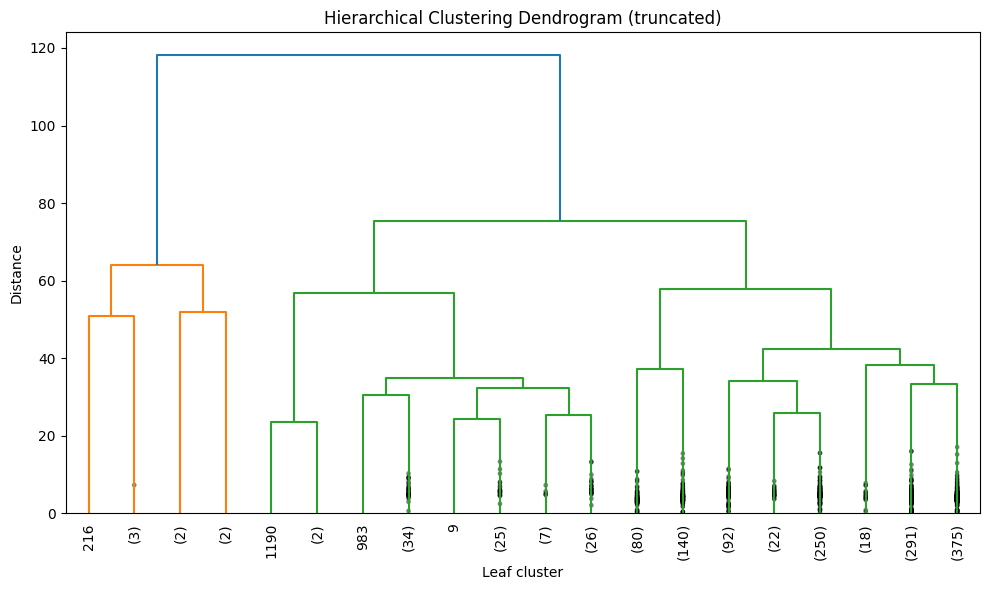

In [ ]:
#6) Truncated dendrogram (readable)

plt.figure(figsize=(10,6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Leaf cluster")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dat Capstone/hierarchical_clustering_dendrogram.png",
            dpi=300, bbox_inches="tight")
plt.show()


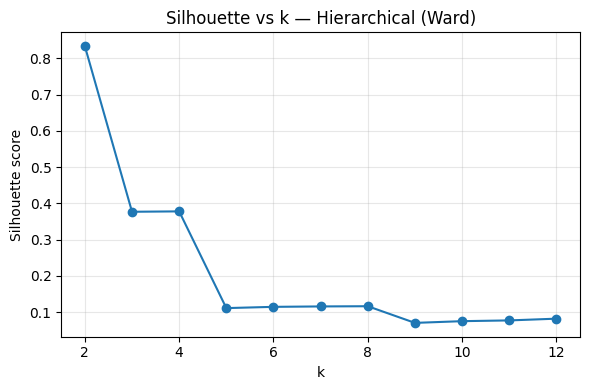

k= 2  silhouette=0.834
k= 3  silhouette=0.377
k= 4  silhouette=0.378
k= 5  silhouette=0.111
k= 6  silhouette=0.115
k= 7  silhouette=0.116
k= 8  silhouette=0.117
k= 9  silhouette=0.071
k=10  silhouette=0.075
k=11  silhouette=0.077
k=12  silhouette=0.082


In [ ]:
#7) Silhouette vs. k (2–12) with Agglomerative (Ward)

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

ks = range(2, 13)
sil_scores = []
for k in ks:
    labels_k = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    sil_scores.append(silhouette_score(X, labels_k))

plt.figure(figsize=(6,4))
plt.plot(list(ks), sil_scores, marker="o")
plt.title("Silhouette vs k — Hierarchical (Ward)")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dat Capstone/silhouetter_vs_k_hierarchical.png",
            dpi=300, bbox_inches="tight")
plt.show()

for k, s in zip(ks, sil_scores):
    print(f"k={k:2d}  silhouette={s:.3f}")


Cluster sizes:
 cluster
0    1268
1       4
2      97
3       4
Name: count, dtype: int64


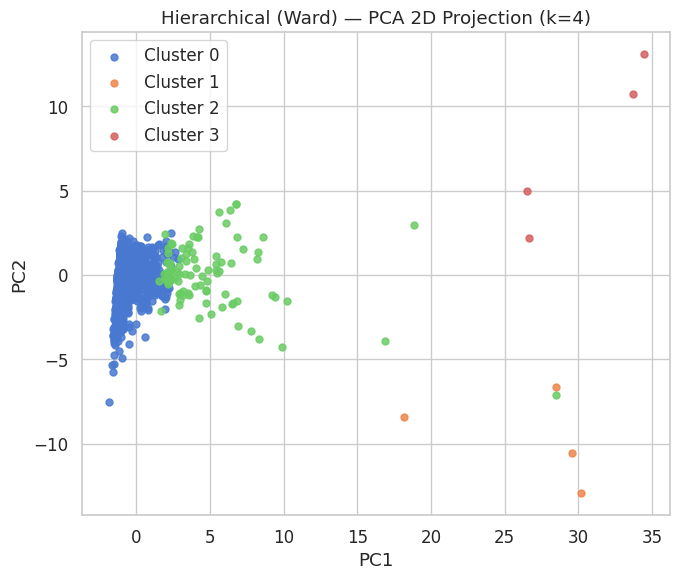

Explained variance ratio (PC1, PC2): [0.2626639 0.0695005]


In [ ]:

#Pick k_best, fit final model, sizes, PCA 2D

from sklearn.decomposition import PCA

k_best = 4  # <-- adjust based on plots above

agg_final = AgglomerativeClustering(n_clusters=k_best, linkage="ward")
labels = agg_final.fit_predict(X)

work["cluster"] = labels
print("Cluster sizes:\n", work["cluster"].value_counts().sort_index())

# PCA projection
pca2 = PCA(n_components=2, random_state=42)
proj2 = pca2.fit_transform(X)

plt.figure(figsize=(7,6))
for c in range(k_best):
    idx = labels == c
    plt.scatter(proj2[idx,0], proj2[idx,1], s=25, alpha=0.85, label=f"Cluster {c}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Hierarchical (Ward) — PCA 2D Projection (k={k_best})")
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dat Capstone/hierarchical_pca_2d_projection.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Explained variance ratio (PC1, PC2):", pca2.explained_variance_ratio_)


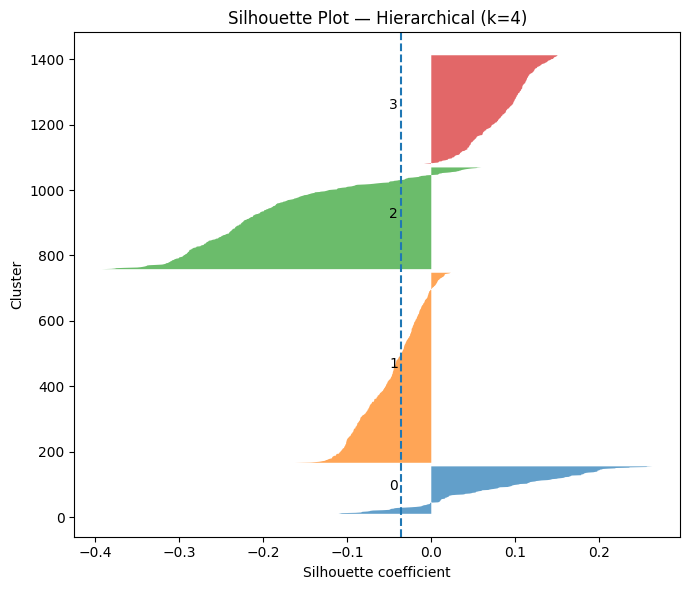

In [ ]:
#9) Silhouette bar plot per cluster

from sklearn.metrics import silhouette_samples
import numpy as np

sample_sil = silhouette_samples(X, labels)
y_lower = 10
plt.figure(figsize=(7,6))
for i in range(k_best):
    ith = sample_sil[labels == i]
    ith.sort()
    size_i = ith.shape[0]
    y_upper = y_lower + size_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5*size_i, str(i))
    y_lower = y_upper + 10

plt.axvline(np.mean(sample_sil), linestyle="--")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.title(f"Silhouette Plot — Hierarchical (k={k_best})")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dat Capstone/silhouetter_plot_hierarchical.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [ ]:

# Numeric summaries
profile_count = work["cluster"].value_counts().sort_index().rename("count")
profile_mean  = work.groupby("cluster")[num_names_kept].mean(numeric_only=True).add_suffix("_mean")
profile_med   = work.groupby("cluster")[num_names_kept].median(numeric_only=True).add_suffix("_median")
profile = pd.concat([profile_count, profile_mean, profile_med], axis=1)

# Optional: top 3 categories per cluster
cat_top = {}
for c in cat_cols:
    cat_top[c] = work.groupby("cluster")[c].agg(lambda s: s.value_counts().head(3))

# Save
profile.to_csv(out_dir/"06_cluster_profile_hierarchical.csv")
labeled = df.copy()
labeled["cluster"] = labels
labeled.to_csv(out_dir/"products_with_clusters_hierarchical.csv", index=False)

print("Saved:")
print(" -", out_dir/"01_last_merges.png")
print(" -", out_dir/"02_dendrogram_truncated.png")
print(" -", out_dir/"03_silhouette_vs_k_hierarchical.png")
print(" -", out_dir/"04_pca2_hierarchical.png")
print(" -", out_dir/"05_silhouette_bars_hierarchical.png")
print(" -", out_dir/"06_cluster_profile_hierarchical.csv")
print(" -", out_dir/"products_with_clusters_hierarchical.csv")


KeyError: 'cluster'

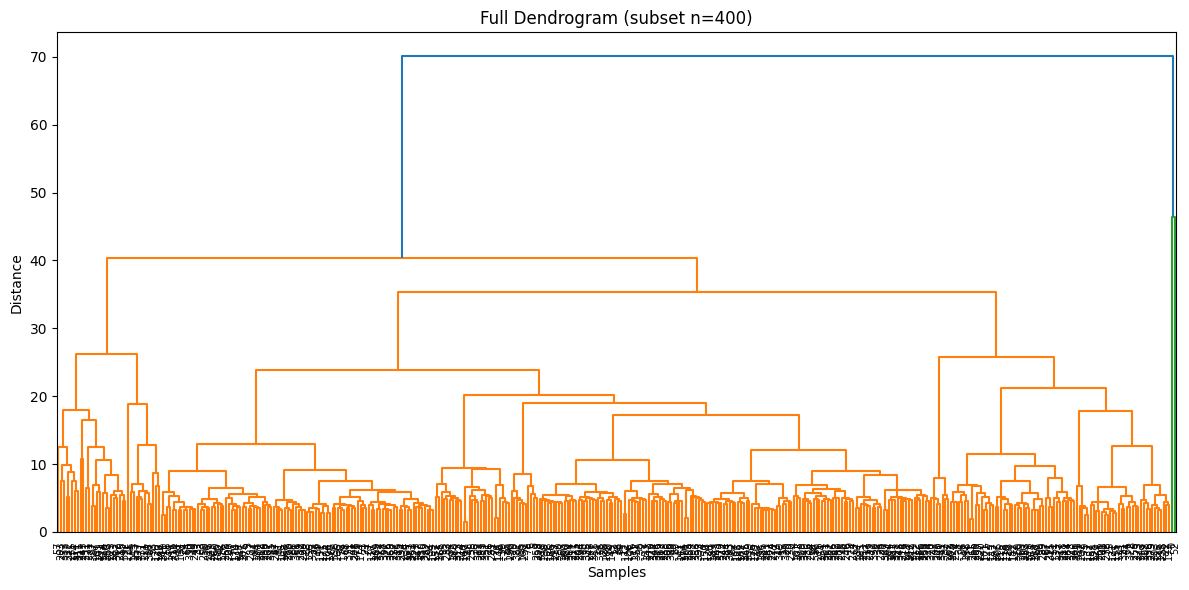

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

subset_n = min(400, X.shape[0])
idx = np.random.choice(X.shape[0], subset_n, replace=False)
Z_sub = linkage(X[idx], method="ward")

plt.figure(figsize=(12,6))
dendrogram(Z_sub, leaf_rotation=90., leaf_font_size=7.)
plt.title(f"Full Dendrogram (subset n={subset_n})")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dat Capstone/full_dendrogram.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [ ]:

!pip -q install pyclustering


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 37.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
base = "/content/drive/MyDrive/Dat Capstone"   # same path you used earlier
csv_path = f"{base}/cleaned_makeup_products.csv"

# Load your products dataset
df = pd.read_csv(csv_path, low_memory=False)

# Drop text / ID / non-numeric columns
drop_cols = [
    "product_link_id","product_link","item_id","product_name",
    "description","pros","cons","best_uses","describe_yourself","brand","category"
]
drop_cols = [c for c in drop_cols if c in df.columns]

# Keep only numeric features
num_cols = [c for c in df.columns if c not in drop_cols]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

numeric_df = df.loc[:, num_cols].dropna(axis=1, how="all")
numeric_df.head()



,price,num_shades,rating,num_reviews,review_star_1,review_star_2,review_star_3,review_star_4,review_star_5,rating_star_1,...,rating_star_3,rating_star_4,rating_star_5,rating_count,review_count,average_rating,recommended_ratio,native_review_count,native_community_content_review_count,syndicated_review_count
0,55.0,NaN,4.4,951.0,286,86,533,17,29,286,...,533,17,29,951,951,4.36,0.91,53,0,898
1,57.0,42.0,4.5,2234.0,35,56,123,507,1513,35,...,123,507,1513,2234,2234,4.53,0.90,64,0,2170
2,44.0,NaN,4.1,3359.0,2033,348,229,240,510,2033,...,229,240,510,3360,3360,4.09,0.81,2254,0,1106
3,55.0,NaN,4.4,5071.0,226,3274,982,403,186,226,...,982,403,186,5071,5071,4.36,0.96,864,0,4207
4,22.0,NaN,4.3,28718.0,1726,1462,2068,4730,18736,1726,...,2068,4730,18736,28722,28722,4.30,0.87,18366,0,10356


In [ ]:
X = numeric_df.fillna(numeric_df.median(numeric_only=True)).copy()
...


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Fill missing values with medians
X = numeric_df.fillna(numeric_df.median(numeric_only=True)).copy()

# Log-transform long-tailed columns (the large-count ones)
skew_cols = [c for c in X.columns if (X[c].max() > 100) and (X[c].min() >= 0)]
for c in skew_cols:
    X[c] = np.log1p(X[c])

# Standardize all numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled shape:", X_scaled.shape)


X_scaled shape: (1373, 21)


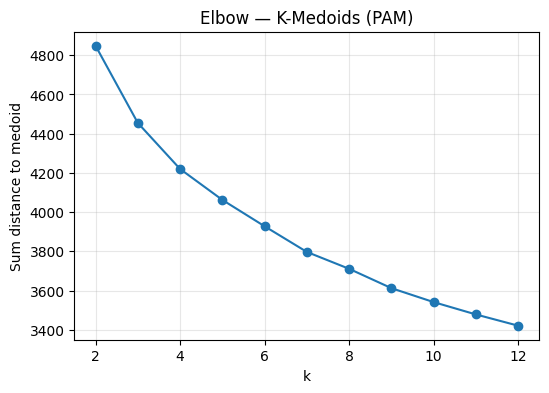

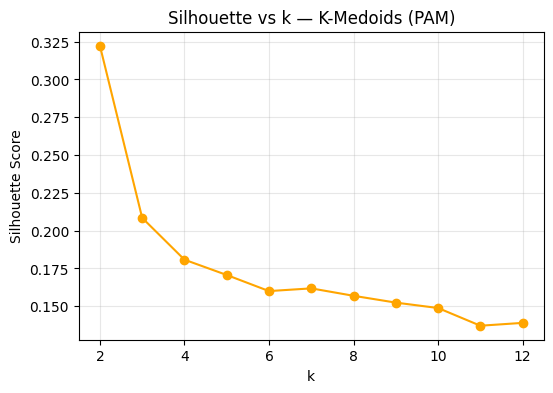

k=2, silhouette=0.322
k=3, silhouette=0.208
k=4, silhouette=0.181
k=5, silhouette=0.171
k=6, silhouette=0.160
k=7, silhouette=0.162
k=8, silhouette=0.157
k=9, silhouette=0.152
k=10, silhouette=0.149
k=11, silhouette=0.137
k=12, silhouette=0.139


In [ ]:
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils.metric import distance_metric, type_metric
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
metric = distance_metric(type_metric.EUCLIDEAN)

def run_kmedoids_for_k(X_scaled, k, n_init=10):
    best = {"sil": -1, "labels": None, "medoids": None}
    n = X_scaled.shape[0]
    for _ in range(n_init):
        init = rng.choice(n, size=k, replace=False).tolist()
        algo = kmedoids(X_scaled.tolist(), init, metric=metric)
        algo.process()
        clusters = algo.get_clusters()
        labels = np.full(n, -1, dtype=int)
        for cid, idxs in enumerate(clusters):
            labels[idxs] = cid
        if (labels >= 0).all():
            sil = silhouette_score(X_scaled, labels)
            if sil > best["sil"]:
                best = {"sil": sil, "labels": labels, "medoids": algo.get_medoids()}
    return best

def total_cost(X_scaled, labels, medoids):
    M = X_scaled[medoids]
    d = np.sqrt(((X_scaled[:,None,:]-M[None,:,:])**2).sum(axis=2)).min(axis=1)
    return d.sum()

ks = range(2, 13)
costs, sils, best_runs = [], [], []
for k in ks:
    res = run_kmedoids_for_k(X_scaled, k, n_init=10)
    best_runs.append(res)
    costs.append(total_cost(X_scaled, res["labels"], res["medoids"]))
    sils.append(res["sil"])

plt.figure(figsize=(6,4))
plt.plot(list(ks), costs, marker="o")
plt.xlabel("k"); plt.ylabel("Sum distance to medoid")
plt.title("Elbow — K-Medoids (PAM)")
plt.grid(alpha=.3);
plt.savefig("/content/drive/MyDrive/Dat Capstone/kmedoids_elbow.png",
            dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(ks), sils, marker="o", color="orange")
plt.xlabel("k"); plt.ylabel("Silhouette Score")
plt.title("Silhouette vs k — K-Medoids (PAM)")
plt.grid(alpha=.3);
plt.savefig("/content/drive/MyDrive/Dat Capstone/kmedoids_silhouette_vs_k.png",
            dpi=300, bbox_inches="tight")
plt.show()

for k, s in zip(ks, sils):
    print(f"k={k}, silhouette={s:.3f}")


Cluster sizes:
 cluster
0    275
1    384
2    434
3    280
Name: count, dtype: int64


,price,num_shades,rating,num_reviews,review_star_1,review_star_2,review_star_3,review_star_4,review_star_5,rating_star_1,...,rating_star_3,rating_star_4,rating_star_5,rating_count,review_count,average_rating,recommended_ratio,native_review_count,native_community_content_review_count,syndicated_review_count
cluster,,,,,,,,,,,,,,,,,,,,,
0,26.56,22.90,4.29,4024.97,913.56,789.35,605.46,662.60,1054.50,914.99,...,605.61,662.85,1055.31,4028.27,4025.47,4.27,0.82,1684.45,0.0,2343.82
1,26.95,22.22,4.29,396.57,99.95,24.22,46.51,60.71,166.02,100.18,...,46.68,60.94,167.68,399.84,397.41,4.27,0.81,121.18,0.0,278.66
2,26.42,15.40,4.22,32.40,8.25,9.34,5.33,3.69,5.83,8.25,...,5.34,3.70,5.83,32.50,32.44,4.22,0.72,21.47,0.0,11.03
3,27.15,22.81,4.46,650.04,106.99,339.63,119.79,55.29,28.80,107.00,...,119.80,55.32,28.82,650.71,650.50,4.44,0.86,170.07,0.0,480.64


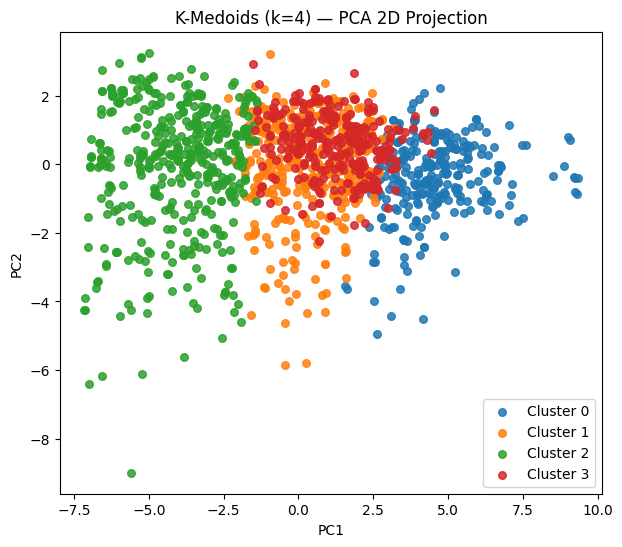

In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples
import numpy as np

k_best = 4  # change this if a different k gives best silhouette
best = best_runs[k_best - ks.start]
labels, medoids = best["labels"], best["medoids"]

df_kmed = df.copy()
df_kmed["cluster"] = labels

print("Cluster sizes:\n", df_kmed["cluster"].value_counts().sort_index())

# Cluster summary
summary = df_kmed.groupby("cluster")[X.columns].mean().round(2)
display(summary)

# PCA plot
pca = PCA(n_components=2, random_state=42)
proj2 = pca.fit_transform(X_scaled)
plt.figure(figsize=(7,6))
for c in range(k_best):
    plt.scatter(proj2[labels==c,0], proj2[labels==c,1], s=30, alpha=.85, label=f"Cluster {c}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"K-Medoids (k={k_best}) — PCA 2D Projection")
plt.legend();
plt.savefig("/content/drive/MyDrive/Dat Capstone/kmedoids_pca2.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
#Show the actual medoid products (representatives).

df.iloc[medoids][["product_name","brand","price","average_rating"]]


,product_name,brand,price,average_rating
556,Liquid Lip Blush & Cheek Tint,Benefit Cosmetics,26.0,4.11
236,Shape Tape Radiant Medium Coverage Concealer,Tarte,32.0,4.28
1078,Mini Translucent Loose Setting Powder Ultra-Blur,Ask A Question,28.0,4.33
1259,Rinse-Off Eye Makeup Remover Solvent,NaN,26.0,4.49


In [ ]:

#Profile clusters (which features separate them most).
Quick stats + effect sizes:
import pandas as pd, numpy as np
prof_mean = df_kmed.groupby("cluster")[X.columns].mean().round(2)
prof_med  = df_kmed.groupby("cluster")[X.columns].median().round(2)
prof_iqr  = df_kmed.groupby("cluster")[X.columns].quantile([.25,.75]).unstack(0)
display(prof_mean); display(prof_med); display(prof_iqr)


SyntaxError: invalid syntax (ipython-input-516163561.py, line 2)

--- Extended EDA ---

/tmp/ipython-input-440378652.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=products, x="category", y="rating", palette="coolwarm")


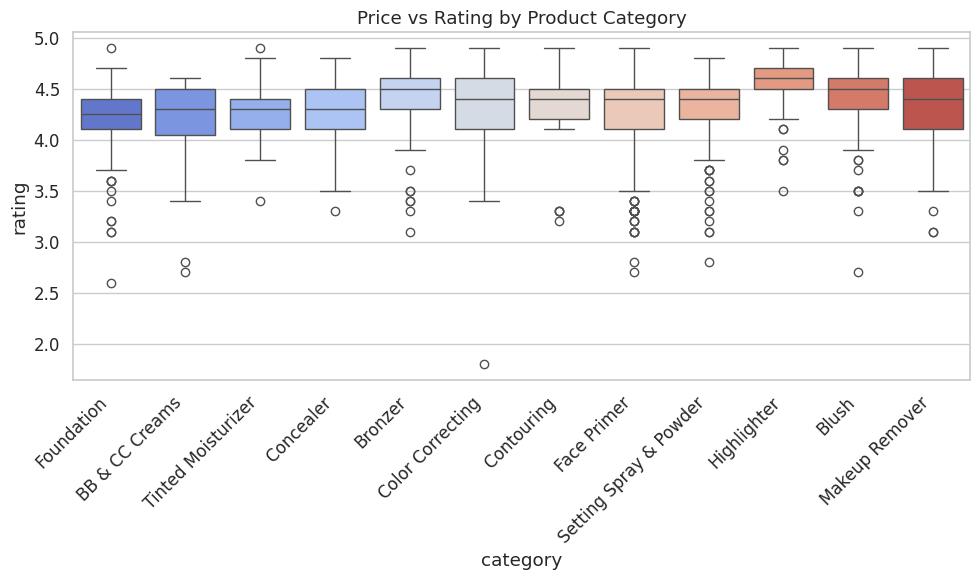

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (8, 6)

plt.figure(figsize=(10,6))
sns.boxplot(data=products, x="category", y="rating", palette="coolwarm")
plt.xticks(rotation=45, ha='right')
plt.title("Price vs Rating by Product Category")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Dat Capstone/price_vs_rating_by_category.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ✅ Clean + prepare
reviews['created_date'] = pd.to_datetime(reviews['created_date'], errors='coerce')
reviews['updated_date'] = pd.to_datetime(reviews['updated_date'], errors='coerce')
reviews['year'] = reviews['created_date'].dt.year
reviews['review_length'] = reviews['comments'].astype(str).str.len()

# --- FIX DATETIME ---
for c in ['created_date', 'updated_date']:
    reviews[c] = pd.to_datetime(reviews[c], errors='coerce', infer_datetime_format=True)

# --- CREATE YEAR COLUMN ---
reviews['year'] = reviews['created_date'].dt.year


/tmp/ipython-input-682157966.py:9: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  reviews[c] = pd.to_datetime(reviews[c], errors='coerce', infer_datetime_format=True)
/tmp/ipython-input-682157966.py:9: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  reviews[c] = pd.to_datetime(reviews[c], errors='coerce', infer_datetime_format=True)


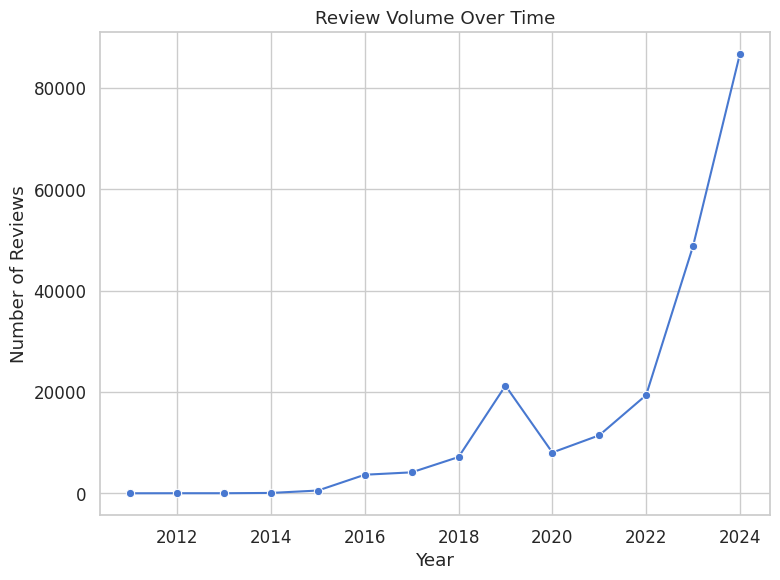

In [ ]:
trend = reviews.groupby('year').size().reset_index(name='review_count')
sns.lineplot(data=trend, x='year', y='review_count', marker='o')
plt.title('Review Volume Over Time')
plt.xlabel('Year'); plt.ylabel('Number of Reviews')
plt.tight_layout();
plt.savefig("/content/drive/MyDrive/Dat Capstone/review_volume_over_time.png",
            dpi=300, bbox_inches="tight")
plt.show()

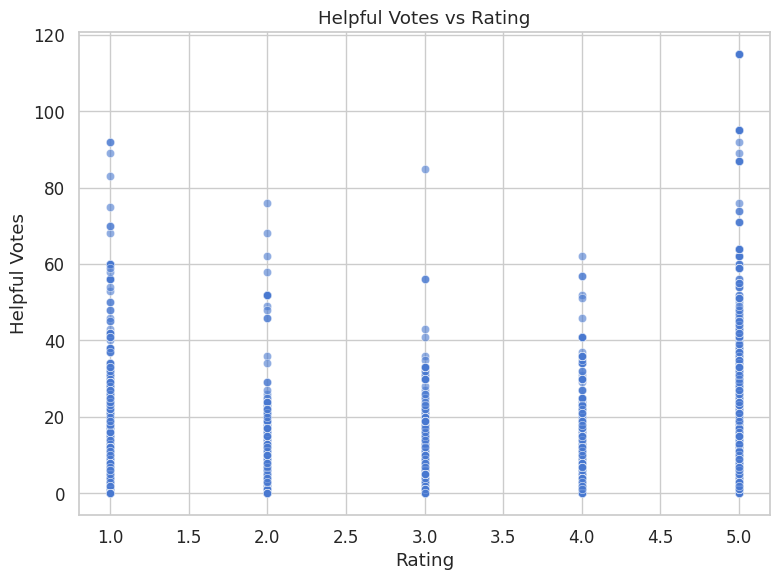

In [ ]:
sns.scatterplot(data=reviews, x='rating', y='helpful_votes', alpha=0.6)
plt.title('Helpful Votes vs Rating')
plt.xlabel('Rating'); plt.ylabel('Helpful Votes')
plt.tight_layout();
plt.savefig("/content/drive/MyDrive/Dat Capstone/helpful_votes_vs_rating.png",
            dpi=300, bbox_inches="tight")
plt.show()

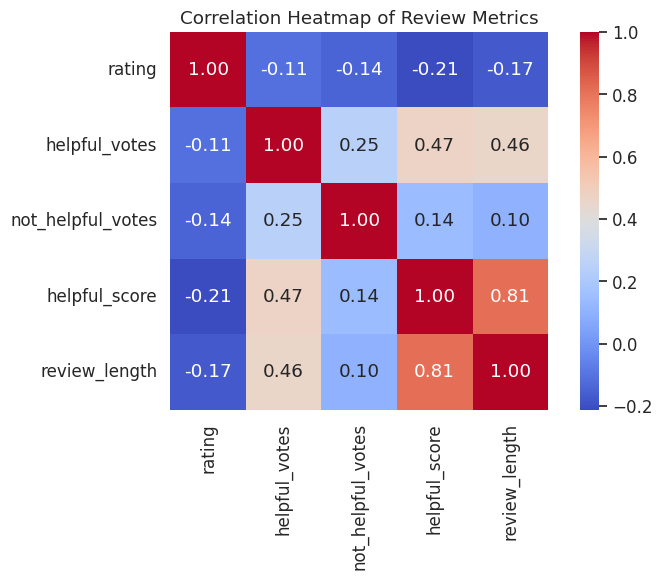

In [ ]:
num_cols = ['rating','helpful_votes','not_helpful_votes','helpful_score','review_length']
corr = reviews[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Review Metrics')
plt.tight_layout();
plt.savefig("/content/drive/MyDrive/Dat Capstone/correlation_heatmap_of_review_metrics.png",
            dpi=300, bbox_inches="tight")
plt.show()

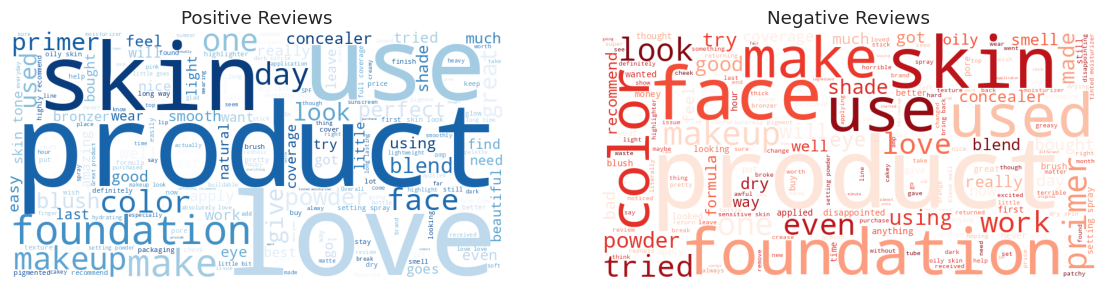

In [ ]:
positive_text = " ".join(reviews.loc[reviews['rating']>=4, 'comments'].dropna().astype(str))
negative_text = " ".join(reviews.loc[reviews['rating']<=2, 'comments'].dropna().astype(str))

wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(positive_text)
wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].imshow(wc_pos); ax[0].set_title('Positive Reviews'); ax[0].axis('off')
ax[1].imshow(wc_neg); ax[1].set_title('Negative Reviews'); ax[1].axis('off')
plt.savefig("/content/drive/MyDrive/Dat Capstone/wordCloud.png",
            dpi=300, bbox_inches="tight")
plt.show()

--Sentiment Analysis--

In [ ]:
!pip install transformers datasets torch seaborn wordcloud scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from sklearn.metrics import classification_report, accuracy_score
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline
import evaluate
import torch
from tqdm import tqdm
from wordcloud import WordCloud
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

redundant_words = set([
    "product", "makeup", "foundation", "concealer", "lipstick",
    "mascara", "powder", "shade", "color", "brand", "buy", "bought",
    "thing", "stuff", "item", "review", "use", "used", "using",
    "work", "works", "like"
])

def clean_text(text):
    text = str(text).lower()

    for brand in brand_list:
        if len(brand.split()) > 8:
            text = text.replace(brand, "")

    # Remove punctuation and digits
    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    # Tokenize
    tokens = text.split()

    # Remove stopwords, redundant words, and short words
    tokens = [
        w for w in tokens
        if w not in stop_words
        and w not in redundant_words
        and len(w) > 2
    ]
    return tokens

ModuleNotFoundError: No module named 'evaluate'

In [ ]:
from transformers import pipeline

sentiment_model = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

In [ ]:
def get_sentiment(texts):
    results = []
    for text in tqdm(texts):
        if isinstance(text, str) and text.strip():
            result = sentiment_model(text[:512])[0]  # truncate long text
            results.append(result['label'])
        else:
            results.append(None)
    return results

In [ ]:
df['positive_sentiment'] = get_sentiment(df['faceoff_positive'])
df['negative_sentiment'] = get_sentiment(df['faceoff_negative'])

In [ ]:
# Convert to numeric score from range of 1-5
df['faceoff_positive_score'] = df['positive_sentiment'].str.extract('(\d)').astype(float)
df['faceoff_negative_score'] = df['negative_sentiment'].str.extract('(\d)').astype(float)

In [ ]:
pos_df = df[['faceoff_positive_score']].copy()
pos_df['text'] = df['faceoff_positive']
pos_df['true_label'] = 'positive'
pos_df.rename(columns={'faceoff_positive_score': 'score'}, inplace=True)

neg_df = df[['faceoff_negative_score']].copy()
neg_df['text'] = df['faceoff_negative']
neg_df['true_label'] = 'negative'
neg_df.rename(columns={'faceoff_negative_score': 'score'}, inplace=True)

combined_df = pd.concat([pos_df, neg_df]).dropna()

In [ ]:
combined_df['predicted_label'] = combined_df['score'].apply(lambda x: 'positive' if x >= 3 else 'negative')

accuracy = accuracy_score(combined_df['true_label'], combined_df['predicted_label'])
print(f"BERT sentiment model accuracy: {accuracy:.2%}")

report = classification_report(
    combined_df['true_label'],
    combined_df['predicted_label'],
    target_names=['negative', 'positive']
)
print("Classification Report:\n", report)

In [ ]:
# Sentiment Distribution

plt.figure(figsize=(8,5))
sns.countplot(x='score', hue='true_label', data=combined_df)
plt.title("Sentiment Rating Distribution (1-5)")
plt.xlabel("Predicted Score")
plt.ylabel("Count")
plt.legend(title="Label")
plt.show()

In [ ]:
# Average sentiment by review type

plt.figure(figsize=(6,4))
sns.barplot(data=combined_df, x='true_label', y='score', palette='coolwarm', ci=None)
plt.title("Average Sentiment Score per Review Type")
plt.xlabel("Known Review Polarity")
plt.ylabel("Average BERT Sentiment Score")
plt.show()

In [ ]:
# Confusion matrix (true vs predicted)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(combined_df['true_label'], combined_df['predicted_label'], labels=['positive','negative'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Negative'])
disp.plot(cmap='Blues')
plt.title("BERT Sentiment Confusion Matrix")
plt.show()

In [ ]:
# Example of using model to predict future new makeup reviews

new_reviews = [
    "This lipstick is amazing! Very pigmented and long-lasting.",
    "The foundation is patchy and dries my skin.",
    "Neutral product, nothing special."
]

for review in new_reviews:
    result = sentiment_model(review)[0]
    print(f"Review: {review}")
    print(f"Predicted sentiment: {result['label']}, Confidence: {result['score']:.2f}\n")

In [ ]:
# Top Brands by Average Sentiment Plot

if 'brand' in df.columns and 'faceoff_positive_score' in df.columns:

    df['sentiment_score'] = df[['faceoff_positive_score','faceoff_negative_score']].mean(axis=1)

    # Clean brand names
    clean_brands = df['brand'].astype(str).str.lower()
    clean_brands = (
        clean_brands
        .str.replace(r'creamy texture', '', regex=True)
        .str.replace(r'smooth blend', '', regex=True)
        .str.replace(r'smooth consistency', '', regex=True)
        .str.replace(r'smooth coverage', '', regex=True)
        .str.replace(r'smooth finish', '', regex=True)
        .str.replace(r'smooth consistensy', '', regex=True)
        .str.strip()
    )
    df['brand'] = clean_brands

    # Drop empty brand names
    df_brand_plot = df[df['brand'] != '']

    # Group by brand and get average sentiment
    brand_sentiment = (
        df_brand_plot.groupby('brand')['sentiment_score']
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )

    plt.figure(figsize=(10,5))
    sns.barplot(x='sentiment_score', y='brand', data=brand_sentiment, palette='Greens_r')
    plt.title("Top 10 Brands by Average Sentiment")
    plt.xlabel("Average Sentiment (1–5 Stars)")
    plt.ylabel("Brand")
    plt.show()

In [ ]:
# Worst Brands by Average Sentiment Plot

 worst_brands = (
        df_brand_plot.groupby('brand')['sentiment_score']
        .mean()
        .sort_values(ascending=True)
        .head(10)
        .reset_index()
    )

 plt.figure(figsize=(10,5))
 sns.barplot(
      x='sentiment_score', y='brand',
      data=worst_brands, palette='Reds_r'
  )
 plt.title("Bottom 10 Brands by Average Sentiment")
 plt.xlabel("Average Sentiment (1–5 Stars)")
 plt.ylabel("Brand")
 plt.show()

In [ ]:
# Top Products Based on Review Sentiment

if 'product_name' in df.columns:
    clean_products = df['product_name'].astype(str).str.lower()

    phrases_to_remove = [
        r'long[-\s]?lasting',
        r'similar to tarte shape tape \(which i love\)',
        r'similar to tarte shape tape',
        r'sits light on your face',
        r'size',
        r'skin match',
        r'skin tone match',
        r'slight matte finish',
        r'small amount goes a long way',
        r'small amount goes long way',
        r'small amounts?',
        r'small container',
        r'smell',
        r'smells great',
        r'smooth and very lightweight!?+',
        r'smooth and creaseless',
        r'smooth and long lasting',
        r'smooth and velvet[-\s]?y feel',
        r'smooth application',
        r'smooth finish',
        r'smooth texture',
        r'smooth\b',
        r'small\b',
    ]

    for phrase in phrases_to_remove:
        clean_products = clean_products.str.replace(phrase, '', regex=True)

    clean_products = clean_products.str.replace(r'\s+', ' ', regex=True).str.strip()
    clean_products = clean_products.replace('', np.nan).fillna(method='bfill')

    df_product_plot = df.copy()
    df_product_plot['product_name'] = clean_products

    product_sent = (
        df_product_plot.groupby('product_name')['sentiment_score']
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )

    # Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(x='sentiment_score', y='product_name', data=product_sent, palette='coolwarm')
    plt.title("Top 10 Products by Average Sentiment")
    plt.xlabel("Average Sentiment (1–5 Stars)")
    plt.ylabel("Product")
    plt.show()